In [1]:
from download_tools import *
from preprocessing import *
from km_estimation import *
import matplotlib.pyplot as plt

In [2]:
sites_southeast = ["02177000", "02178400", "03455500", "03500000", "02143500"]
sites_texas_ok = ["08167500", "08171000", "08195000", "07311500", "07332500"]
sites_mountain = ["06043500", "06191500", "09065500", "09066000", "09085000"]
sites_pnw = ["14158500", "14306500", "12189500"]
sites_newengland = ["01052500", "01055000"]

sites = sites_southeast + sites_texas_ok + sites_mountain + sites_pnw + sites_newengland

start_date = "2005-01-01"
end_date = "2026-01-01"
dt = 15

y_col = '00065' #Depth
target_folder = 'data'


def main():
    # # Step 1: Download (do once, save raw_data)
    results = {}
    raw_data = get_all_sites(sites, target_folder, start_date, end_date)
    for site_id, site_data in raw_data.items():
        if '00065' not in site_data.columns:
            print(f"Missing '00065' in {site_id}")
            print(f"Available columns: {site_data.columns.tolist()}")
            continue
        site_dictionary = create_site_dictionary(site_data, dt= dt, omega = 0.49,c=2, std_window=50)
        compute_KM(site_dictionary)
        results[site_id] = site_dictionary
    return results


In [3]:
results = main()

c:\Users\hmont\Documents\Duke\Calculus of Sustainability\Project\SDE_Stage\SDE_Analysis\download_tools.py:56: DtypeWarning: Columns (3,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0, parse_dates=True)
c:\Users\hmont\Documents\Duke\Calculus of Sustainability\Project\SDE_Stage\SDE_Analysis\download_tools.py:56: DtypeWarning: Columns (3,7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0, parse_dates=True)
c:\Users\hmont\Documents\Duke\Calculus of Sustainability\Project\SDE_Stage\SDE_Analysis\download_tools.py:56: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0, parse_dates=True)
c:\Users\hmont\Documents\Duke\Calculus of Sustainability\Project\SDE_Stage\SDE_Analysis\download_tools.py:56: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set 

Missing '00065' in 08171000
Available columns: ['site_no', '00060_15-minute updates', '00060_15-minute updates_cd', '00065_primary sensor 15 min. updates', '00065_primary sensor 15 min. updates_cd', '00065_secondary sen. 15-min. updates', '00065_secondary sen. 15-min. updates_cd']


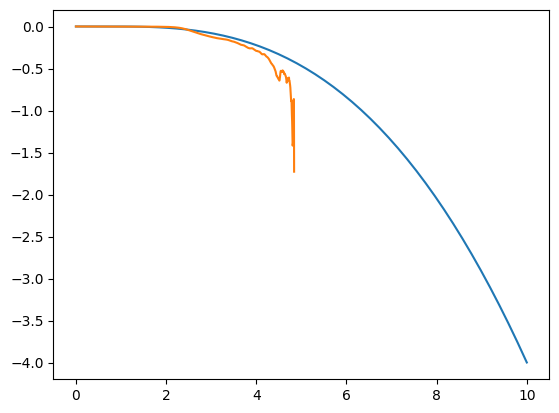

In [21]:
# Import from the models folder
from Models.piecewise import LinearPowerLaw

site = sites[3]
edges = results[site]['KM_results']['edges']
moments = results[site]['KM_results']['F1']

drift_model = LinearPowerLaw()
drift_model.fit(edges, moments)
drift_model.params
y_fit = np.linspace(0,10)
drift_fit = drift_model.evaluate(y_fit)

plt.plot(y_fit, drift_fit)
plt.plot(edges,moments)
